In this notebook we explore how neural networks can approximate (i.e. mimick) any function.

The first step is to set up the random seed so the results are consistent across the runs



In [1]:
#setup random seed for reproducibility
import tensorflow
tensorflow.keras.utils.set_random_seed(2)
tensorflow.config.experimental.enable_op_determinism()

Let's define the function to be approximated. We'll go for something simple: a parabola!

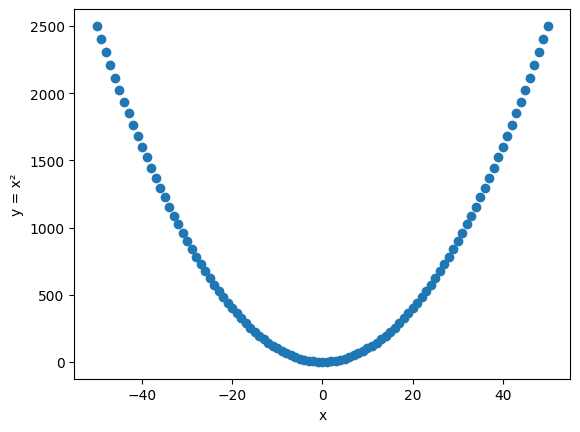

In [2]:
import numpy as np

# define x
x = np.array([i for i in range(-50,51)])

# our function: y = x²
y = x * x

# let's plot and see what we have
from matplotlib import pyplot
pyplot.scatter(x,y)
pyplot.xlabel('x')
pyplot.ylabel('y = x²')
pyplot.show()

We are now defining a simple network that will learn/approximate/mimick the relationship between x and y.

In [4]:
#define the model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(10, input_dim=1, activation='relu', kernel_initializer='he_uniform')) #he_uniform initializes the network's weights before training using a scaled random uniform distribution, designed to work well with ReLU activations by compensating for the variance lost when ReLU zeroes out negative values.
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1))

#compile the model
model.compile(loss='mse', optimizer='adam')

#train the model
h = model.fit(x, y, epochs=500, batch_size=10, verbose=0)

2026-05-23 08:15:55.221935: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


We define a couple of functions for plots

In [5]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

def plot_history(h, title, target='loss'):
	"""
	Given a history dictionary as returned by model.fit(), plots the required
	variable with the specified title. If present, validation is also
	plotted.

	Parameter:
	h (dict) : history object returned by keras model.fit()
	title : title for the plot
	target : name of the variable to be plotted

	Returns: nothing
	"""
	plt.rcParams["figure.figsize"]=5,5
	plt.plot(h.history[target], label = "Train " + target)
	#validation
	val_label = 'val_'+ target
	if val_label in h.history:
		plt.plot(h.history['val_'+target], label = "Validation " + target)
	plt.xlabel('Epochs')
	plt.title(title)
	plt.legend()
	plt.show()

def plot_function(title, common_x, actual_y, predicted_y=None):
  """
	Plots either one or two series of data against a common x. This is geared
  toward big (publication-ready) figures, with the first series being the true
  y values and the second one, optional, of the predicted ones. Only if both series
  are present the legend is shown.

  Parameters
  title: title of the plot
  common_x: common x-axis values
  actual_y: real y values
  predicted_y: predicted y values, optional

	Returns: nothing
	"""
  figure(figsize=(16, 12), dpi=80)
  pyplot.rc('xtick',labelsize=20)
  pyplot.rc('ytick',labelsize=20)

  #plot the results
  pyplot.scatter(common_x, actual_y,    80, label='Actual')
  if predicted_y is not None:
    pyplot.scatter(common_x, predicted_y, 80, label='Predicted', edgecolors='red', facecolors='red', marker='o')
    pyplot.legend(fontsize=30, frameon=False)
  pyplot.title(title, fontsize=40)
  pyplot.xlabel('Input Variable (x)', fontsize=20)
  pyplot.ylabel('Output Variable (y)', fontsize=20)
  pyplot.show()


Let's take a look to our training trajectory

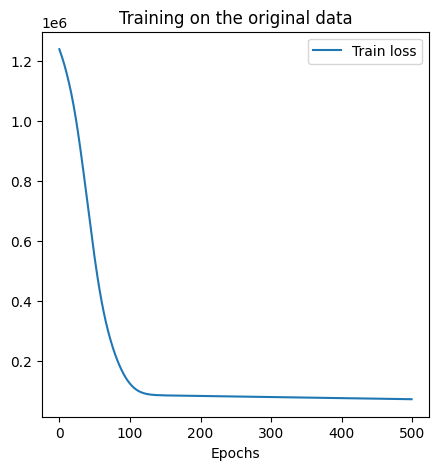

In [6]:
plot_history(h, title = 'Training on the original data')

We now feed again the x values to the model to retrieve its predictions (usually marked as ŷ, read "y hat"):

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


2026-05-23 08:16:43.606097: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


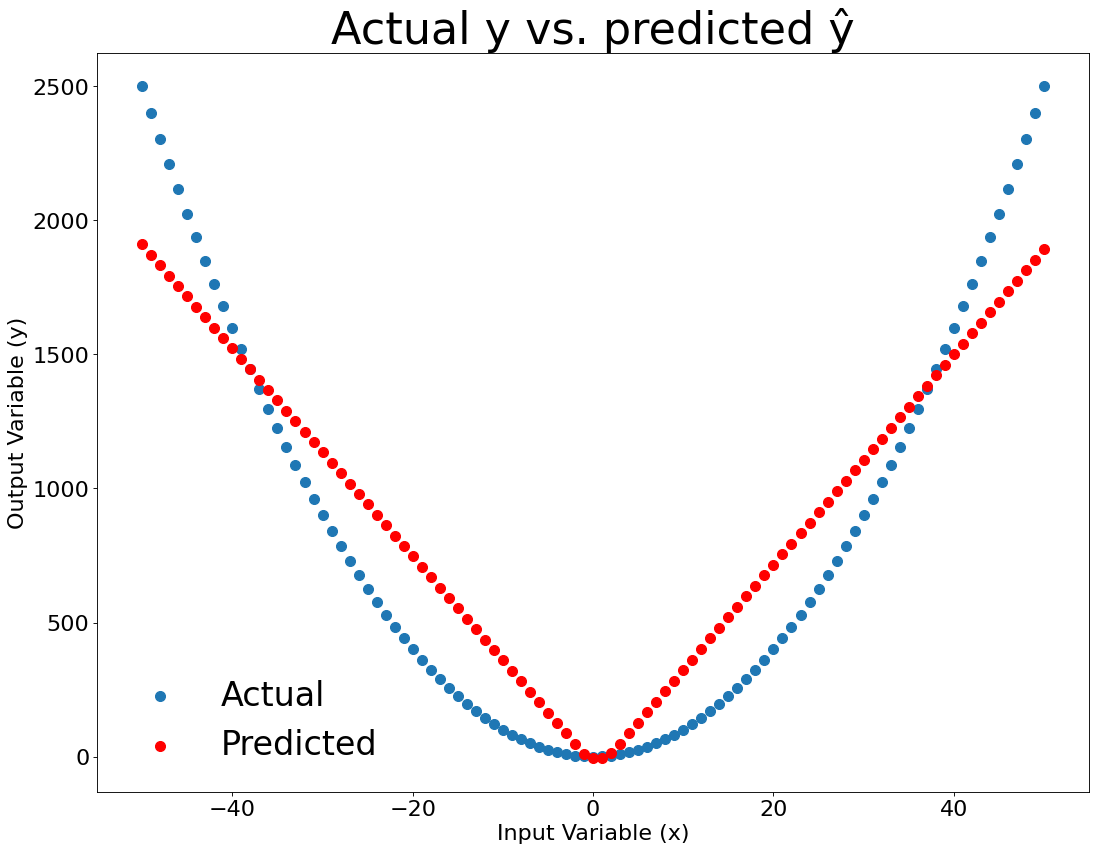

In [7]:
#use the trained model to predict the ŷ corresponding to the input x
yhat = model.predict(x)

#a plot comparing ŷ to actual y
plot_function(title='Actual y vs. predicted ŷ', common_x=x, actual_y=y, predicted_y=yhat)

This seems less than optimal, but it's mainly due to our model not liking the scale of the values (both x and y). We now redo the full procedure, but scale x and y in between zero and one

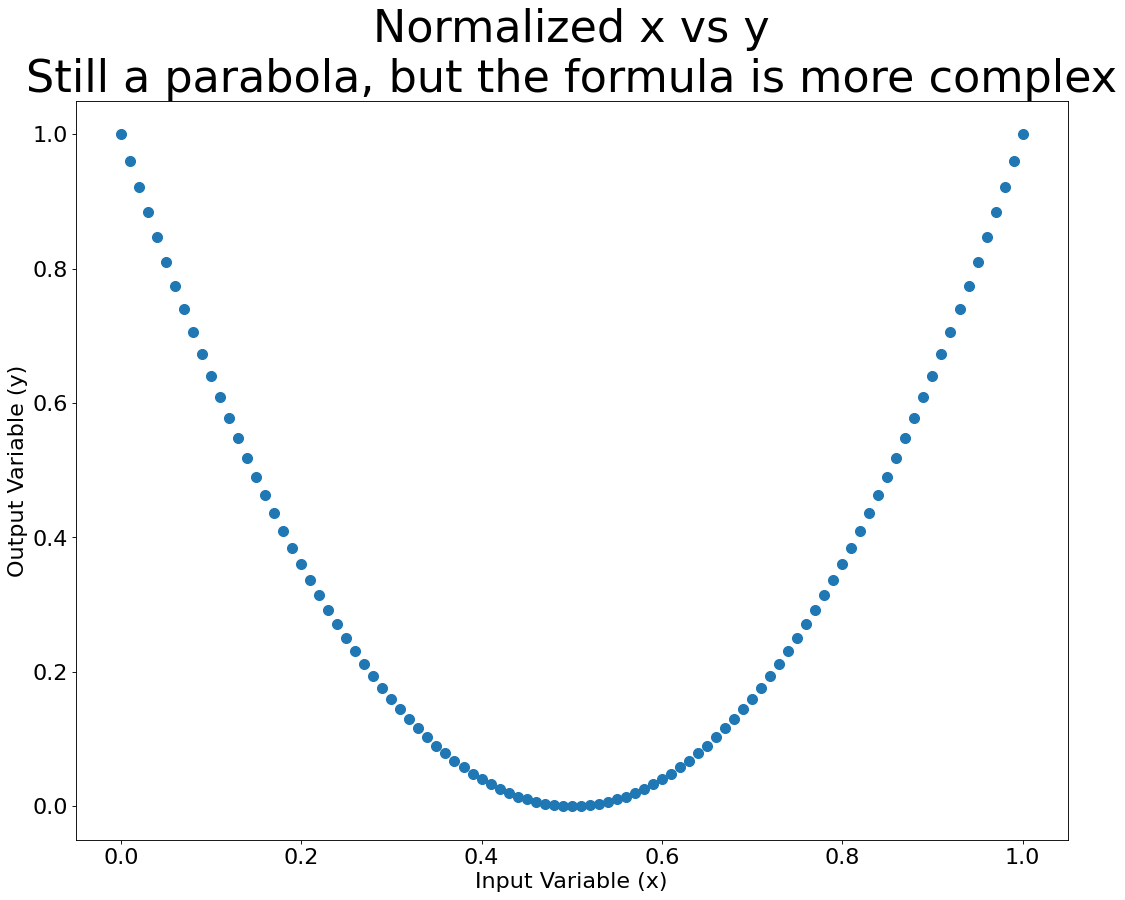

In [8]:
#normalize between zero and one both x and y
x_normalized = (x - x.min()) / ((x.max() - x.min()))
y_normalized = (y - y.min()) / ((y.max() - y.min()))

# let's plot the normalized output
plot_function(title='Normalized x vs y\nStill a parabola, but the formula is more complex', common_x=x_normalized, actual_y=y_normalized)

In [9]:
#declare a new, pristine model
model = Sequential()
model.add(Dense(10, input_dim=1, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1))

#compile the model
model.compile(loss='mse', optimizer='adam')

#train on the normalized values
h = model.fit(x_normalized, y_normalized, epochs=500, batch_size=10, verbose=0)

2026-05-23 08:17:13.120657: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


taking a look at our training trajectory

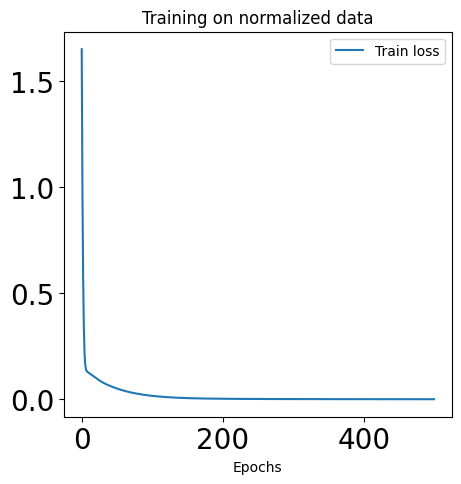

In [10]:
plot_history(h, title = 'Training on normalized data')

Comparing true and predicted values

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


2026-05-23 08:19:49.690202: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


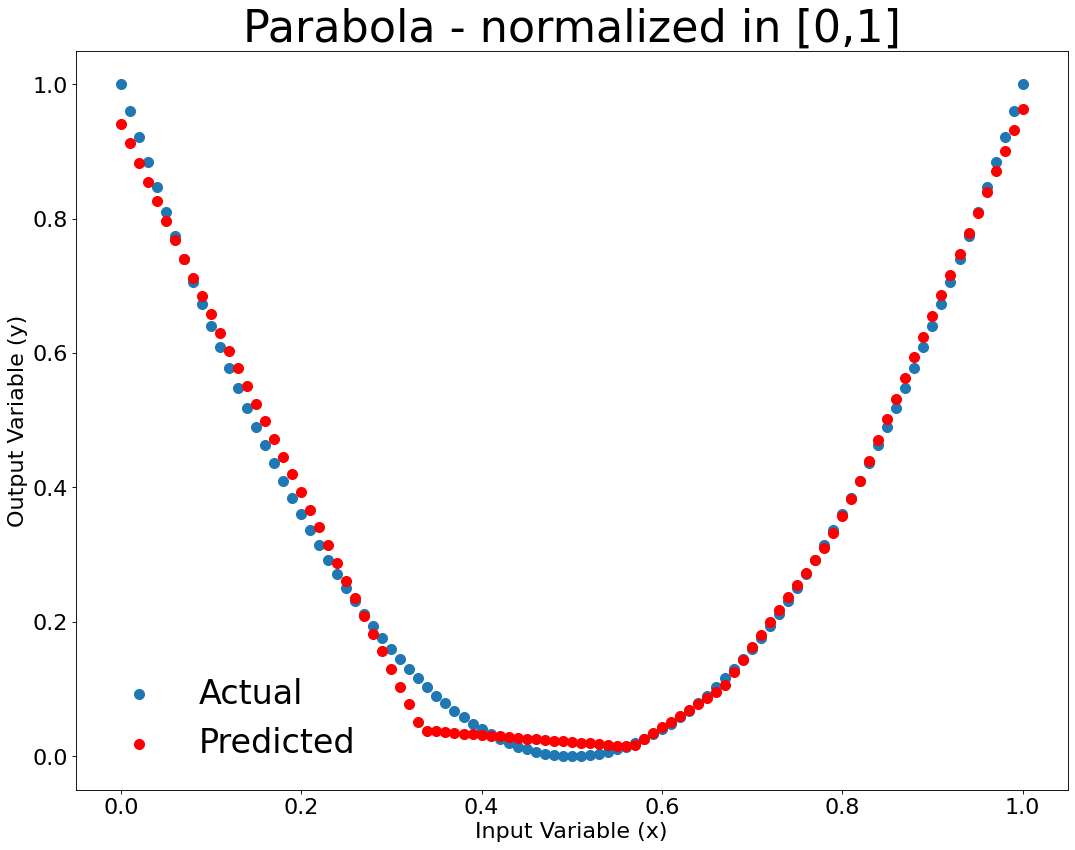

In [11]:
y_normalized_hat = model.predict(x_normalized)
plot_function(title='Parabola - normalized in [0,1]', common_x=x_normalized, actual_y=y_normalized, predicted_y=y_normalized_hat)

Same thing, with a third grade polynomial

2026-05-23 08:19:55.975555: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x141fe49a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


2026-05-23 08:20:02.380934: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


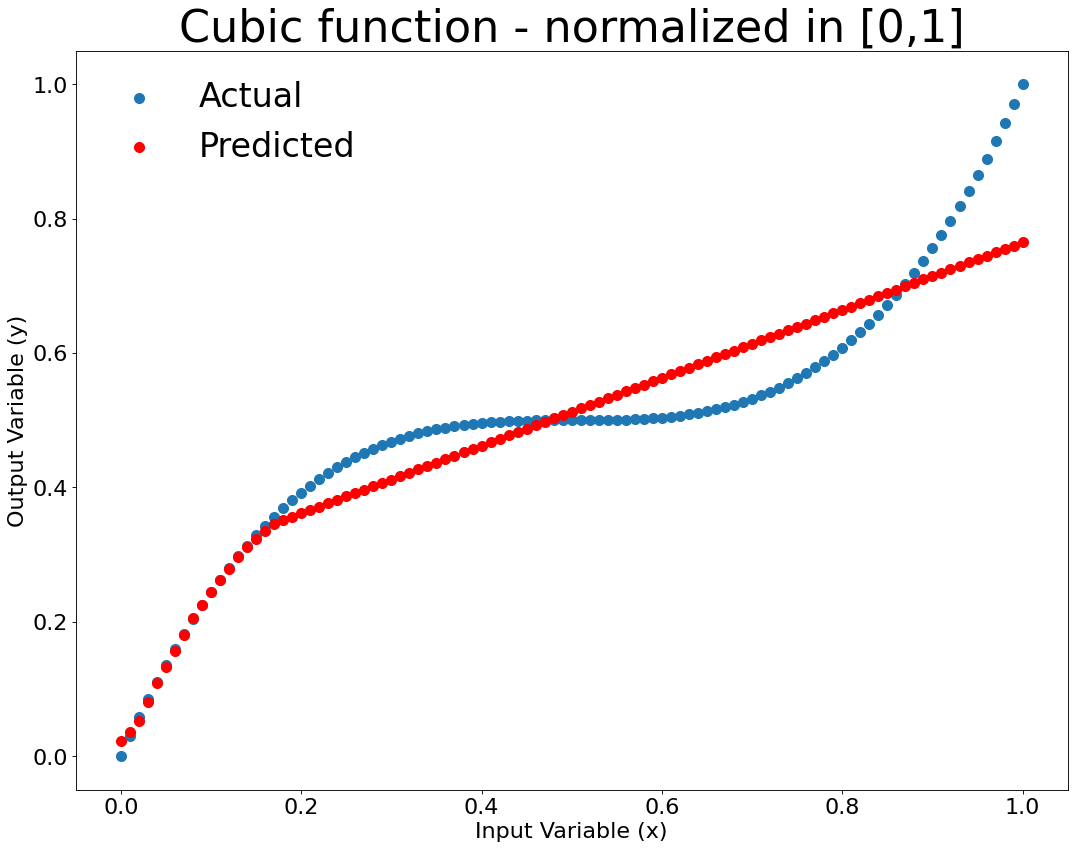

In [12]:
# define x and y = x³ - x
x = np.array([i for i in range(-50,51)])
y = x * x * x - x

#normalize
x_normalized = (x - x.min()) / ((x.max() - x.min()))
y_normalized = (y - y.min()) / ((y.max() - y.min()))

#define the network
model = Sequential()
model.add(Dense(10, input_dim=1, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1))

#compile the model
model.compile(loss='mse', optimizer='adam')

#train on the normalized values
h = model.fit(x_normalized, y_normalized, epochs=500, batch_size=10, verbose=0)

#repredict the input
y_normalized_hat = model.predict(x_normalized)

#plot the results
plot_function(title='Cubic function - normalized in [0,1]', common_x=x_normalized, actual_y=y_normalized, predicted_y=y_normalized_hat)